In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
data = pd.read_csv("/content/LoanApprovalPrediction+.csv")

In [ ]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
print('Missing values in each column:')
print(data.isnull().sum())

Missing values in each column:
Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64


In [ ]:
# Fill missing values
# For numerical columns, we use the mean or median
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mean())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

# Verify no more missing values
print('Missing values after cleanup:')
print(data.isnull().sum())

Missing values after cleanup:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
print(data['Gender'].unique())

data['Gender'] = le.fit_transform(data['Gender'])

print(data['Gender'].unique())

['Male' 'Female']
[1 0]


In [ ]:
print(data['Education'].unique())

data['Education'] = le.fit_transform(data['Education'])

print(data['Education'].unique())

['Graduate' 'Not Graduate']
[0 1]


In [ ]:
print(data['Married'].unique())

data['Married'] = le.fit_transform(data['Married'])

print(data['Married'].unique())

['No' 'Yes']
[0 1]


In [ ]:
print(data['Self_Employed'].unique())

data['Self_Employed'] = le.fit_transform(data['Self_Employed'])

print(data['Self_Employed'].unique())

['No' 'Yes']
[0 1]


In [ ]:
print(data['Property_Area'].unique())

data['Property_Area'] = le.fit_transform(data['Property_Area'])

print(data['Property_Area'].unique())

['Urban' 'Rural' 'Semiurban']
[2 0 1]


In [ ]:
print(data['Loan_Status'].unique())

data['Loan_Status'] = le.fit_transform(data['Loan_Status'])

print(data['Loan_Status'].unique())

['Y' 'N']
[1 0]


In [ ]:
loan_count = data['Loan_Status'].value_counts()

Text(0, 0.5, 'Count')

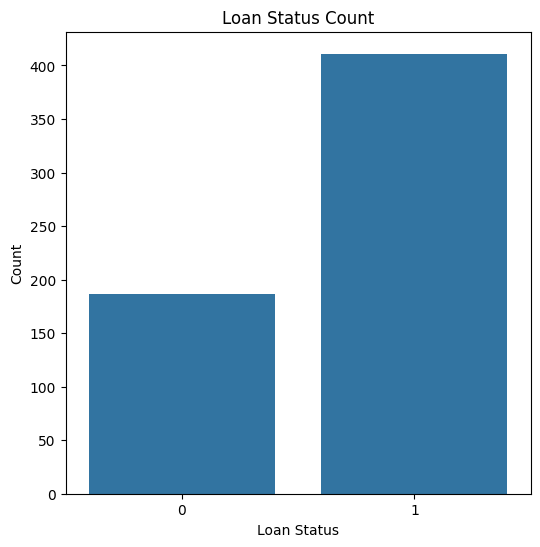

In [ ]:
plt.figure(figsize=(6,6))
sns.barplot(x=loan_count.index, y=loan_count.values)
plt.title('Loan Status Count')
plt.xlabel('Loan Status')
plt.ylabel('Count')

Text(0.5, 1.0, 'Loan Status Count')

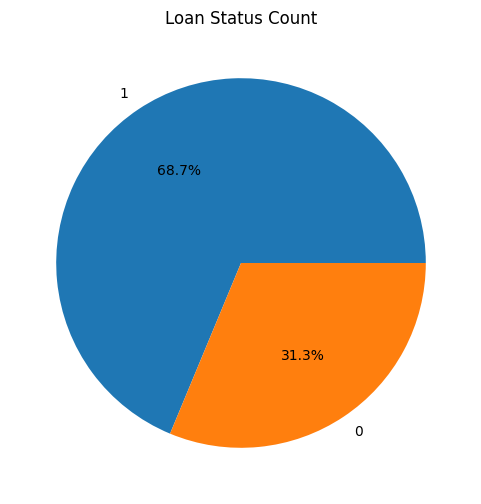

In [ ]:
# piechart

plt.figure(figsize=(6,6))
plt.pie(loan_count.values, labels=loan_count.index, autopct='%1.1f%%')
plt.title('Loan Status Count')

In [ ]:
# split the data to X and Y, where X is input independed cos and Y is output dependent cols

X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
Y = data['Loan_Status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=2)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [150]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Calculate accuracy
Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Model Accuracy: 77.78%
Confusion Matrix:
[[16 15]
 [ 5 54]]
